# Examen 1 - Clasificacion de Rendimiento Estudiantil

Notebook de trabajo para:
- explorar visualmente el conjunto de datos;
- entrenar el MLP requerido por el enunciado;
- compararlo contra KNN, Random Forest y una variante con SMOTE;
- generar tablas y figuras para el reporte IEEE.


## 1. Librerias y configuracion

In [19]:
import sys
print(sys.executable)


/home/dgx/jupyterlab/.venv/bin/python3


In [20]:
import os
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from imblearn.over_sampling import SMOTE
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import ParameterGrid, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from tensorflow import keras

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

BASE_DIR = Path.cwd()
RAW_DATASET = BASE_DIR / 'Student_performance_data _ - Student_performance_data _.csv'
CLEAN_DATASET = BASE_DIR / 'Student_performance_data_clean.csv'

COLUMNAS_CONTINUAS = ['Age', 'StudyTimeWeekly', 'Absences']
COLUMNAS_CATEGORICAS = [
    'Gender', 'Ethnicity', 'ParentalEducation', 'Tutoring',
    'ParentalSupport', 'Extracurricular', 'Sports', 'Music', 'Volunteering'
]
COLUMNA_OBJETIVO = 'GradeClass'

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
sns.set_theme(style='whitegrid')


## 2. Carga y limpieza

In [21]:
def reparar_decimal(valor):
    texto = str(valor).strip()
    if not texto:
        return np.nan
    if texto.count('.') <= 1:
        return float(texto)
    parte_entera, parte_decimal = texto.split('.', 1)
    digitos = parte_decimal.replace('.', '')
    return float(f'{parte_entera}.{digitos}')

if CLEAN_DATASET.exists():
    df = pd.read_csv(CLEAN_DATASET)
else:
    df = pd.read_csv(RAW_DATASET)
    for columna in ['StudyTimeWeekly', 'GPA']:
        df[columna] = df[columna].map(reparar_decimal)
    df.to_csv(CLEAN_DATASET, index=False)

df[COLUMNA_OBJETIVO] = df[COLUMNA_OBJETIVO].astype(int)
df['StudyTimeWeekly'] = df['StudyTimeWeekly'].astype(float)
df['GPA'] = df['GPA'].astype(float)

print('Forma del conjunto de datos:', df.shape)
print('\nNulos por columna:')
print(df.isna().sum())
print('\nDistribucion de clases:')
print(df[COLUMNA_OBJETIVO].value_counts().sort_index())
df.head()


Forma del conjunto de datos: (2392, 15)

Nulos por columna:
StudentID            0
Age                  0
Gender               0
Ethnicity            0
ParentalEducation    0
StudyTimeWeekly      0
Absences             0
Tutoring             0
ParentalSupport      0
Extracurricular      0
Sports               0
Music                0
Volunteering         0
GPA                  0
GradeClass           0
dtype: int64

Distribucion de clases:
GradeClass
0     107
1     269
2     391
3     414
4    1211
Name: count, dtype: int64


,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4


## 2.1 Analisis visual del conjunto de datos

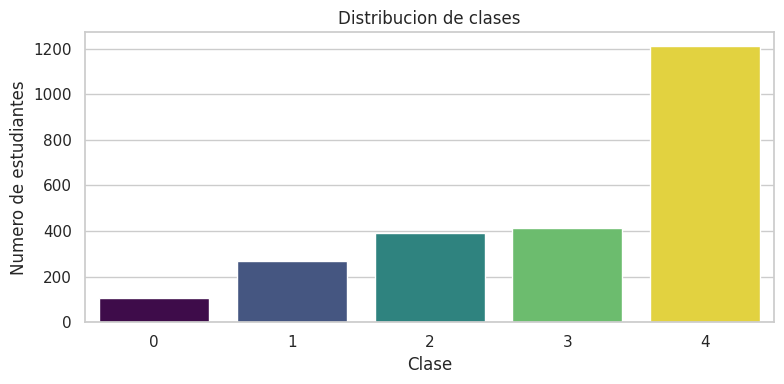

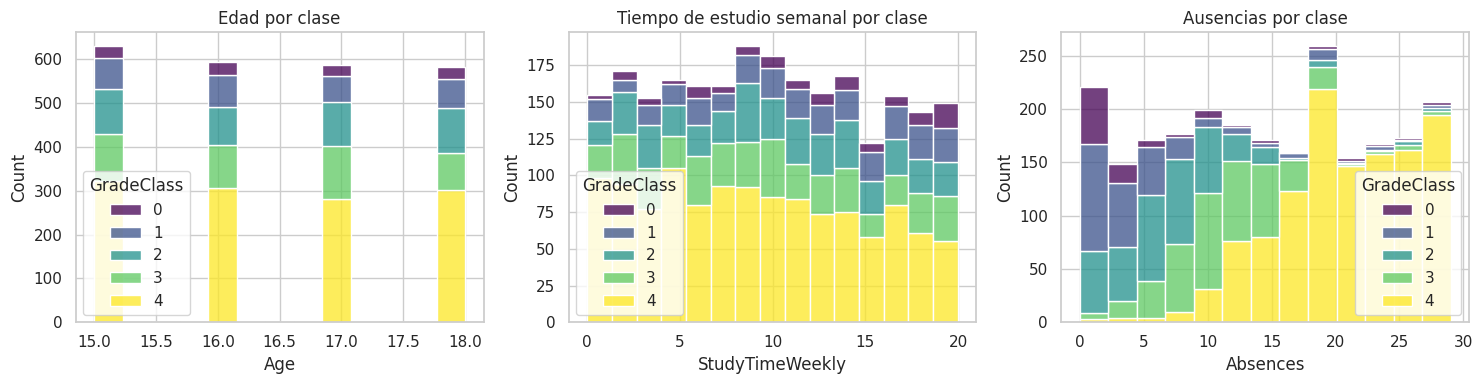

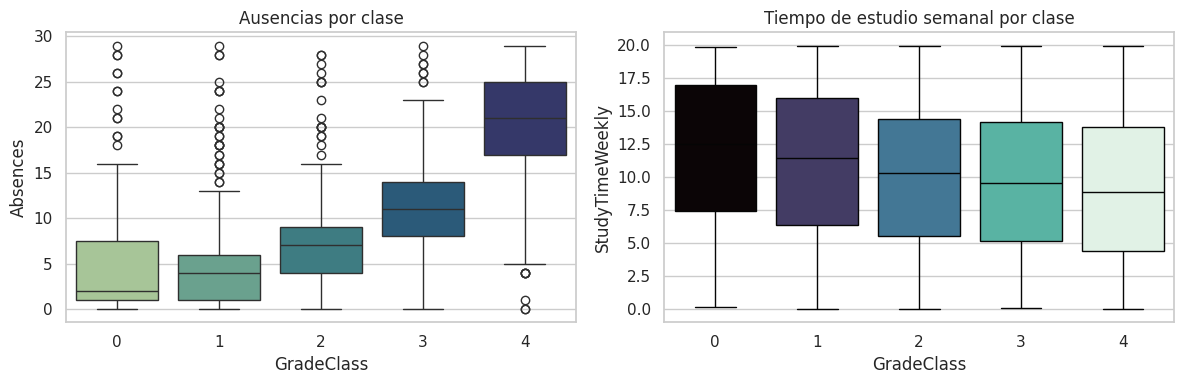

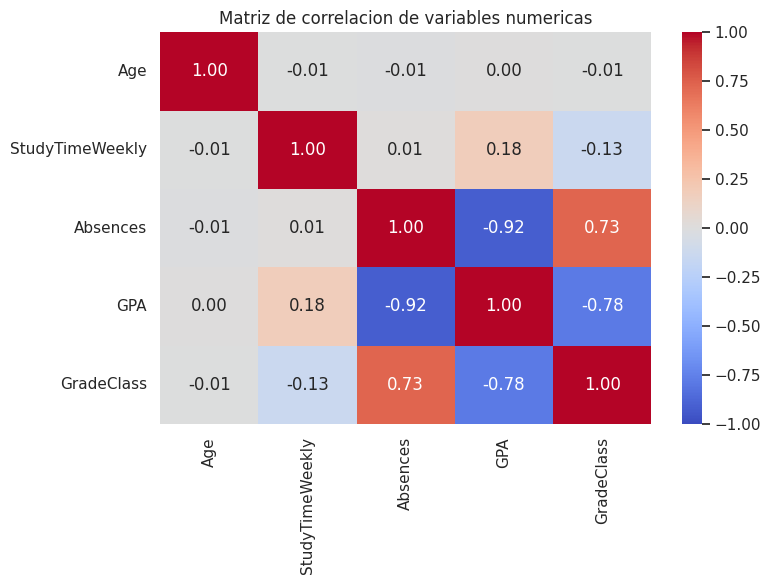

In [22]:
plt.figure(figsize=(8, 4))
orden = sorted(df[COLUMNA_OBJETIVO].unique())
sns.countplot(data=df, x=COLUMNA_OBJETIVO, hue=COLUMNA_OBJETIVO, order=orden, dodge=False, palette='viridis', legend=False)
plt.title('Distribucion de clases')
plt.xlabel('Clase')
plt.ylabel('Numero de estudiantes')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(data=df, x='Age', hue='GradeClass', multiple='stack', ax=axes[0], palette='viridis')
axes[0].set_title('Edad por clase')
sns.histplot(data=df, x='StudyTimeWeekly', hue='GradeClass', multiple='stack', ax=axes[1], palette='viridis')
axes[1].set_title('Tiempo de estudio semanal por clase')
sns.histplot(data=df, x='Absences', hue='GradeClass', multiple='stack', ax=axes[2], palette='viridis')
axes[2].set_title('Ausencias por clase')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=df, x='GradeClass', y='Absences', ax=axes[0], hue='GradeClass', dodge=False, palette='crest', legend=False)
axes[0].set_title('Ausencias por clase')
sns.boxplot(data=df, x='GradeClass', y='StudyTimeWeekly', ax=axes[1], hue='GradeClass', dodge=False, palette='mako', legend=False)
axes[1].set_title('Tiempo de estudio semanal por clase')
plt.tight_layout()
plt.show()

columnas_numericas = ['Age', 'StudyTimeWeekly', 'Absences', 'GPA', 'GradeClass']
plt.figure(figsize=(8, 6))
sns.heatmap(df[columnas_numericas].corr(), annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Matriz de correlacion de variables numericas')
plt.tight_layout()
plt.show()


## 3. Particion y preprocesamiento

Nota metodologica:
- `GPA` se excluye para evitar fuga de informacion.
- `StudentID` se excluye por ser un identificador.


In [23]:
columnas_entrada = COLUMNAS_CONTINUAS + COLUMNAS_CATEGORICAS
X = df[columnas_entrada]
y = df[COLUMNA_OBJETIVO].to_numpy()

X_train_df, X_temp_df, y_train, y_temp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=SEED)
X_val_df, X_test_df, y_val, y_test = train_test_split(X_temp_df, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED)

preprocesador = ColumnTransformer([
    ('continuas', StandardScaler(), COLUMNAS_CONTINUAS),
    ('categoricas', OneHotEncoder(handle_unknown='ignore', sparse_output=False), COLUMNAS_CATEGORICAS),
])

X_train = np.asarray(preprocesador.fit_transform(X_train_df), dtype=np.float32)
X_val = np.asarray(preprocesador.transform(X_val_df), dtype=np.float32)
X_test = np.asarray(preprocesador.transform(X_test_df), dtype=np.float32)

print('Entrenamiento:', X_train.shape)
print('Validacion:', X_val.shape)
print('Prueba:', X_test.shape)


Entrenamiento: (1674, 29)
Validacion: (359, 29)
Prueba: (359, 29)


## 4. Funciones auxiliares

In [24]:
def recopilar_metricas(y_real, y_pred):
    return {
        'exactitud': accuracy_score(y_real, y_pred),
        'precision_macro': precision_score(y_real, y_pred, average='macro', zero_division=0),
        'sensibilidad_macro': recall_score(y_real, y_pred, average='macro', zero_division=0),
        'puntaje_f1_macro': f1_score(y_real, y_pred, average='macro', zero_division=0),
    }

def mostrar_matriz_confusion(y_real, y_pred, etiquetas, titulo):
    cm = confusion_matrix(y_real, y_pred, labels=etiquetas, normalize='true')
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', xticklabels=[f'Clase {i}' for i in etiquetas], yticklabels=[f'Clase {i}' for i in etiquetas])
    plt.title(titulo)
    plt.xlabel('Prediccion')
    plt.ylabel('Valor real')
    plt.tight_layout()
    plt.show()

def construir_optimizador(nombre, tasa_aprendizaje):
    if nombre == 'adam':
        return keras.optimizers.Adam(learning_rate=tasa_aprendizaje)
    if nombre == 'sgd':
        return keras.optimizers.SGD(learning_rate=tasa_aprendizaje, momentum=0.9, nesterov=True)
    return keras.optimizers.RMSprop(learning_rate=tasa_aprendizaje)

def construir_mlp_requerido(dimension_entrada, numero_clases, nombre_optimizador='adam', tasa_aprendizaje=1e-3, usar_batch_norm=False):
    capas = [keras.layers.Input(shape=(dimension_entrada,)), keras.layers.Dense(200, activation='relu')]
    if usar_batch_norm:
        capas.append(keras.layers.BatchNormalization())
    capas.append(keras.layers.Dropout(0.2))
    capas.append(keras.layers.Dense(200, activation='relu'))
    if usar_batch_norm:
        capas.append(keras.layers.BatchNormalization())
    capas.append(keras.layers.Dropout(0.2))
    capas.append(keras.layers.Dense(150, activation='relu'))
    if usar_batch_norm:
        capas.append(keras.layers.BatchNormalization())
    capas.append(keras.layers.Dropout(0.2))
    capas.append(keras.layers.Dense(200, activation='relu'))
    if usar_batch_norm:
        capas.append(keras.layers.BatchNormalization())
    capas.append(keras.layers.Dropout(0.2))
    capas.append(keras.layers.Dense(numero_clases, activation='softmax'))
    modelo = keras.Sequential(capas)
    modelo.compile(optimizer=construir_optimizador(nombre_optimizador, tasa_aprendizaje), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return modelo

def evaluar_mlp(modelo, x_prueba, y_prueba):
    pred = np.argmax(modelo.predict(x_prueba, verbose=0), axis=1)
    return pred, recopilar_metricas(y_prueba, pred)

def graficar_historial(historial, titulo_base):
    historia = pd.DataFrame(historial.history)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(historia.index + 1, historia['accuracy'], label='Entrenamiento')
    axes[0].plot(historia.index + 1, historia['val_accuracy'], label='Validacion')
    axes[0].set_title(f'{titulo_base} - Exactitud')
    axes[0].set_xlabel('Epoca')
    axes[0].set_ylabel('Exactitud')
    axes[0].legend()
    axes[1].plot(historia.index + 1, historia['loss'], label='Entrenamiento')
    axes[1].plot(historia.index + 1, historia['val_loss'], label='Validacion')
    axes[1].set_title(f'{titulo_base} - Perdida')
    axes[1].set_xlabel('Epoca')
    axes[1].set_ylabel('Perdida')
    axes[1].legend()
    plt.tight_layout()
    plt.show()

def graficar_metricas(df_metricas, titulo):
    df_largo = df_metricas.melt(id_vars='modelo', value_vars=['exactitud', 'precision_macro', 'sensibilidad_macro', 'puntaje_f1_macro'], var_name='metrica', value_name='valor')
    plt.figure(figsize=(12, 5))
    sns.barplot(data=df_largo, x='metrica', y='valor', hue='modelo')
    plt.title(titulo)
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()


## 5. MLP base del examen

In [25]:
mlp_base = construir_mlp_requerido(X_train.shape[1], len(np.unique(y_train)), nombre_optimizador='sgd', tasa_aprendizaje=1e-3, usar_batch_norm=False)
callbacks_base = [keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)]
historial_base = mlp_base.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=50, batch_size=32, verbose=0, callbacks=callbacks_base)
pred_base, metricas_base = evaluar_mlp(mlp_base, X_test, y_test)
metricas_base


{'exactitud': 0.7465181058495822,
 'precision_macro': 0.5300859561910775,
 'sensibilidad_macro': 0.5655642873093156,
 'puntaje_f1_macro': 0.545845849916776}

## 6. K vecinos mas cercanos (KNN)

In [26]:
modelo_knn = KNeighborsClassifier(n_neighbors=7, weights='uniform', metric='euclidean')
modelo_knn.fit(X_train, y_train)
pred_knn = modelo_knn.predict(X_test)
metricas_knn = recopilar_metricas(y_test, pred_knn)
metricas_knn


{'exactitud': 0.6128133704735376,
 'precision_macro': 0.437291107326039,
 'sensibilidad_macro': 0.4176031194313704,
 'puntaje_f1_macro': 0.4226948198085922}

## 7. Variante del MLP con ajustes de entrenamiento

In [27]:
rejilla_mlp = {'optimizer': ['adam', 'sgd'], 'learning_rate': [1e-3, 5e-4], 'batch_size': [32, 64], 'epochs': [50, 100]}
clases = np.unique(y_train)
conteos = np.bincount(y_train)
pesos_clase = {i: len(y_train) / (len(clases) * conteos[i]) for i in clases}

resultados_mlp = []
mejor_modelo_mlp = None
mejor_historial_mlp = None
mejor_config_mlp = None
mejor_f1_mlp = -1
mejor_perdida_mlp = np.inf

for config in ParameterGrid(rejilla_mlp):
    random.seed(SEED)
    np.random.seed(SEED)
    tf.random.set_seed(SEED)
    modelo = construir_mlp_requerido(X_train.shape[1], len(np.unique(y_train)), nombre_optimizador=config['optimizer'], tasa_aprendizaje=config['learning_rate'], usar_batch_norm=True)
    callbacks = [
        keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)
    ]
    historial = modelo.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=config['epochs'], batch_size=config['batch_size'], verbose=0, callbacks=callbacks, class_weight=pesos_clase)
    pred_val = np.argmax(modelo.predict(X_val, verbose=0), axis=1)
    metricas_val = recopilar_metricas(y_val, pred_val)
    perdida_val = float(np.min(historial.history['val_loss']))
    resultados_mlp.append({
        **config,
        'epocas_ejecutadas': len(historial.history['loss']),
        'exactitud_validacion': round(metricas_val['exactitud'], 4),
        'sensibilidad_macro_validacion': round(metricas_val['sensibilidad_macro'], 4),
        'puntaje_f1_macro_validacion': round(metricas_val['puntaje_f1_macro'], 4),
        'mejor_perdida_validacion': round(perdida_val, 4)
    })
    if metricas_val['puntaje_f1_macro'] > mejor_f1_mlp or (np.isclose(metricas_val['puntaje_f1_macro'], mejor_f1_mlp) and perdida_val < mejor_perdida_mlp):
        mejor_f1_mlp = metricas_val['puntaje_f1_macro']
        mejor_perdida_mlp = perdida_val
        mejor_modelo_mlp = modelo
        mejor_historial_mlp = historial
        mejor_config_mlp = dict(config)

df_resultados_mlp = pd.DataFrame(resultados_mlp).sort_values(['puntaje_f1_macro_validacion', 'mejor_perdida_validacion'], ascending=[False, True])
pred_mlp_mejorado, metricas_mlp_mejorado = evaluar_mlp(mejor_modelo_mlp, X_test, y_test)
df_resultados_mlp


,batch_size,epochs,learning_rate,optimizer,epocas_ejecutadas,exactitud_validacion,sensibilidad_macro_validacion,puntaje_f1_macro_validacion,mejor_perdida_validacion
10,64,50,0.0005,adam,34,0.7019,0.6133,0.6164,0.9131
14,64,100,0.0005,adam,34,0.7019,0.6133,0.6164,0.9131
0,32,50,0.0010,adam,27,0.6992,0.5887,0.5890,0.9329
4,32,100,0.0010,adam,27,0.6992,0.5887,0.5890,0.9329
1,32,50,0.0010,sgd,27,0.6992,0.5989,0.5872,0.9215
5,32,100,0.0010,sgd,27,0.6992,0.5989,0.5872,0.9215
3,32,50,0.0005,sgd,33,0.6769,0.5998,0.5764,0.9319
7,32,100,0.0005,sgd,33,0.6769,0.5998,0.5764,0.9319
9,64,50,0.0010,sgd,37,0.6741,0.5644,0.5628,0.8886
13,64,100,0.0010,sgd,37,0.6741,0.5644,0.5628,0.8886


## 8. Variante con SMOTE

In [28]:
print('Distribucion original en entrenamiento:', dict(zip(*np.unique(y_train, return_counts=True))))
smote = SMOTE(random_state=SEED)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
print('Distribucion con SMOTE:', dict(zip(*np.unique(y_train_smote, return_counts=True))))

rejilla_smote = {'optimizer': ['adam', 'sgd'], 'batch_size': [32, 64], 'epochs': [100, 150]}
resultados_smote = []
mejor_modelo_smote = None
mejor_historial_smote = None
mejor_config_smote = None
mejor_f1_smote = -1

for config in ParameterGrid(rejilla_smote):
    random.seed(SEED)
    np.random.seed(SEED)
    tf.random.set_seed(SEED)
    modelo = construir_mlp_requerido(X_train_smote.shape[1], len(np.unique(y_train_smote)), nombre_optimizador=config['optimizer'], tasa_aprendizaje=1e-3, usar_batch_norm=False)
    callbacks = [keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)]
    historial = modelo.fit(X_train_smote, y_train_smote, validation_data=(X_val, y_val), epochs=config['epochs'], batch_size=config['batch_size'], verbose=0, callbacks=callbacks)
    pred_val = np.argmax(modelo.predict(X_val, verbose=0), axis=1)
    metricas_val = recopilar_metricas(y_val, pred_val)
    resultados_smote.append({
        **config,
        'epocas_ejecutadas': len(historial.history['loss']),
        'exactitud_validacion': round(metricas_val['exactitud'], 4),
        'sensibilidad_macro_validacion': round(metricas_val['sensibilidad_macro'], 4),
        'puntaje_f1_macro_validacion': round(metricas_val['puntaje_f1_macro'], 4),
        'mejor_perdida_validacion': round(float(np.min(historial.history['val_loss'])), 4)
    })
    if metricas_val['puntaje_f1_macro'] > mejor_f1_smote:
        mejor_f1_smote = metricas_val['puntaje_f1_macro']
        mejor_modelo_smote = modelo
        mejor_historial_smote = historial
        mejor_config_smote = dict(config)

df_resultados_smote = pd.DataFrame(resultados_smote).sort_values(['puntaje_f1_macro_validacion', 'mejor_perdida_validacion'], ascending=[False, True])
pred_smote, metricas_smote = evaluar_mlp(mejor_modelo_smote, X_test, y_test)
df_resultados_smote


Distribucion original en entrenamiento: {0: 75, 1: 188, 2: 274, 3: 290, 4: 847}
Distribucion con SMOTE: {0: 847, 1: 847, 2: 847, 3: 847, 4: 847}


,batch_size,epochs,optimizer,epocas_ejecutadas,exactitud_validacion,sensibilidad_macro_validacion,puntaje_f1_macro_validacion,mejor_perdida_validacion
1,32,100,sgd,36,0.7465,0.6172,0.6111,0.8365
3,32,150,sgd,36,0.7465,0.6172,0.6111,0.8365
5,64,100,sgd,58,0.7437,0.6161,0.6093,0.8313
7,64,150,sgd,58,0.7437,0.6161,0.6093,0.8313
0,32,100,adam,16,0.7437,0.5984,0.5901,0.8124
2,32,150,adam,16,0.7437,0.5984,0.5901,0.8124
4,64,100,adam,17,0.7187,0.5967,0.5885,0.8326
6,64,150,adam,17,0.7187,0.5967,0.5885,0.8326


## 9. Random Forest basado en literatura

In [29]:
rejilla_rf = {'n_estimators': [200, 400], 'max_depth': [None, 10, 20], 'min_samples_leaf': [1, 2, 4], 'class_weight': [None, 'balanced']}
resultados_rf = []
mejor_modelo_rf = None
mejor_config_rf = None
mejor_f1_rf = -1

for config in ParameterGrid(rejilla_rf):
    modelo = RandomForestClassifier(
        n_estimators=config['n_estimators'],
        max_depth=config['max_depth'],
        min_samples_leaf=config['min_samples_leaf'],
        class_weight=config['class_weight'],
        random_state=SEED,
        n_jobs=-1,
    )
    modelo.fit(X_train, y_train)
    pred_val = modelo.predict(X_val)
    metricas_val = recopilar_metricas(y_val, pred_val)
    resultados_rf.append({
        **config,
        'exactitud_validacion': round(metricas_val['exactitud'], 4),
        'sensibilidad_macro_validacion': round(metricas_val['sensibilidad_macro'], 4),
        'puntaje_f1_macro_validacion': round(metricas_val['puntaje_f1_macro'], 4)
    })
    if metricas_val['puntaje_f1_macro'] > mejor_f1_rf:
        mejor_f1_rf = metricas_val['puntaje_f1_macro']
        mejor_modelo_rf = modelo
        mejor_config_rf = dict(config)

df_resultados_rf = pd.DataFrame(resultados_rf).sort_values(['puntaje_f1_macro_validacion', 'exactitud_validacion'], ascending=[False, False])
pred_rf = mejor_modelo_rf.predict(X_test)
metricas_rf = recopilar_metricas(y_test, pred_rf)
df_resultados_rf.head(10)


,class_weight,max_depth,min_samples_leaf,n_estimators,exactitud_validacion,sensibilidad_macro_validacion,puntaje_f1_macro_validacion
26,balanced,10.0,2,200,0.6852,0.5277,0.5328
23,balanced,NaN,4,400,0.6825,0.5286,0.5297
35,balanced,20.0,4,400,0.6825,0.5286,0.5297
28,balanced,10.0,4,200,0.6769,0.5269,0.5266
24,balanced,10.0,1,200,0.6825,0.5110,0.5248
22,balanced,NaN,4,200,0.6741,0.5204,0.5244
34,balanced,20.0,4,200,0.6741,0.5204,0.5244
27,balanced,10.0,2,400,0.6769,0.5181,0.5215
21,balanced,NaN,2,400,0.6825,0.5112,0.5179
33,balanced,20.0,2,400,0.6825,0.5112,0.5179


## 10. Curvas y visualizaciones de entrenamiento

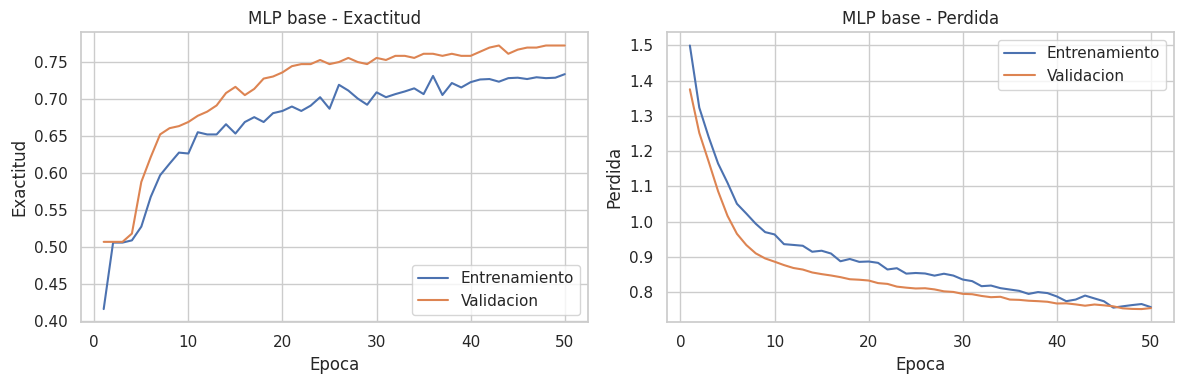

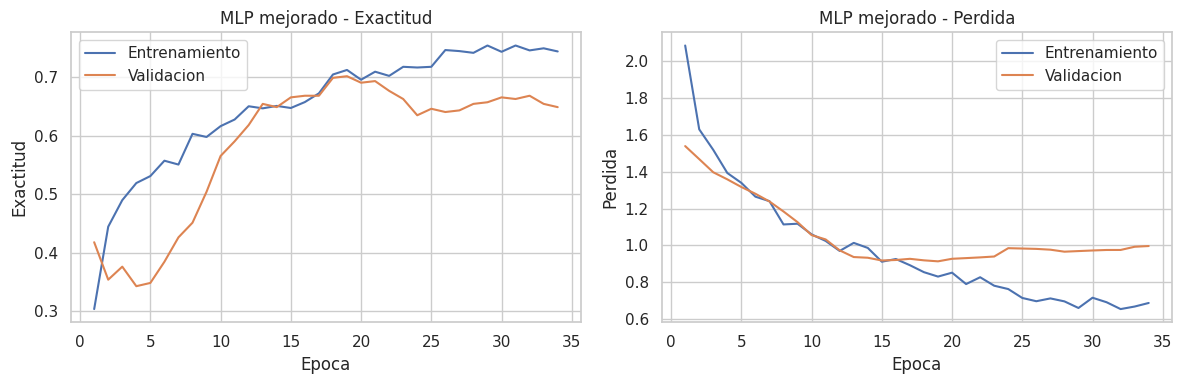

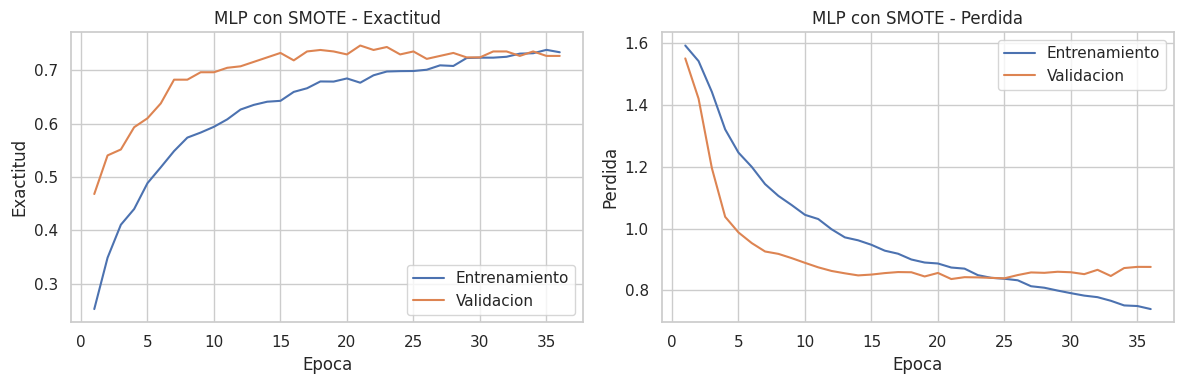

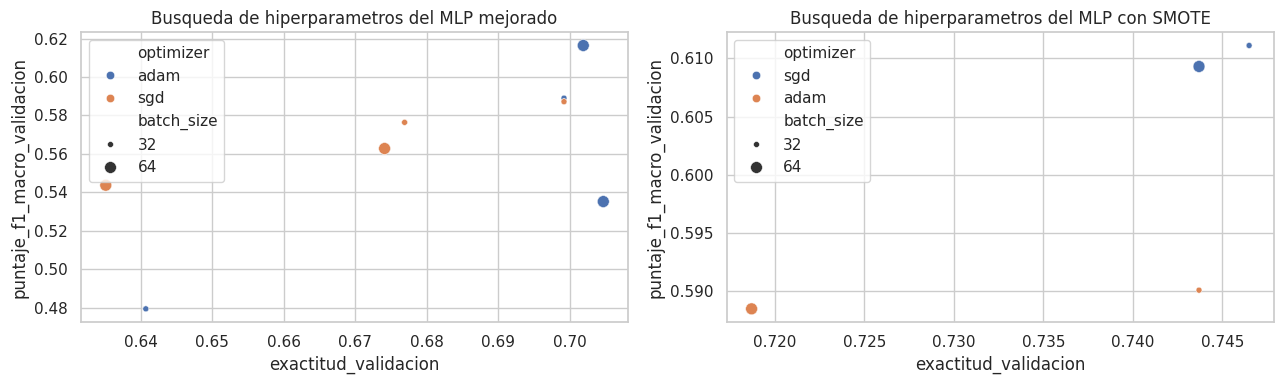

In [30]:
graficar_historial(historial_base, 'MLP base')
graficar_historial(mejor_historial_mlp, 'MLP mejorado')
graficar_historial(mejor_historial_smote, 'MLP con SMOTE')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.scatterplot(data=df_resultados_mlp, x='exactitud_validacion', y='puntaje_f1_macro_validacion', hue='optimizer', size='batch_size', ax=axes[0])
axes[0].set_title('Busqueda de hiperparametros del MLP mejorado')
sns.scatterplot(data=df_resultados_smote, x='exactitud_validacion', y='puntaje_f1_macro_validacion', hue='optimizer', size='batch_size', ax=axes[1])
axes[1].set_title('Busqueda de hiperparametros del MLP con SMOTE')
plt.tight_layout()
plt.show()


## 11. Comparacion final de modelos

In [31]:
df_comparacion = pd.DataFrame([
    {'modelo': 'MLP base', **metricas_base},
    {'modelo': 'KNN', **metricas_knn},
    {'modelo': 'MLP mejorado', **metricas_mlp_mejorado},
    {'modelo': 'MLP con SMOTE', **metricas_smote},
    {'modelo': 'Random Forest', **metricas_rf},
]).sort_values(['puntaje_f1_macro', 'exactitud'], ascending=[False, False]).reset_index(drop=True)
df_comparacion


,modelo,exactitud,precision_macro,sensibilidad_macro,puntaje_f1_macro
0,MLP con SMOTE,0.724234,0.590125,0.590939,0.581847
1,MLP base,0.746518,0.530086,0.565564,0.545846
2,MLP mejorado,0.646240,0.546983,0.539757,0.533065
3,Random Forest,0.685237,0.523859,0.511100,0.515031
4,KNN,0.612813,0.437291,0.417603,0.422695


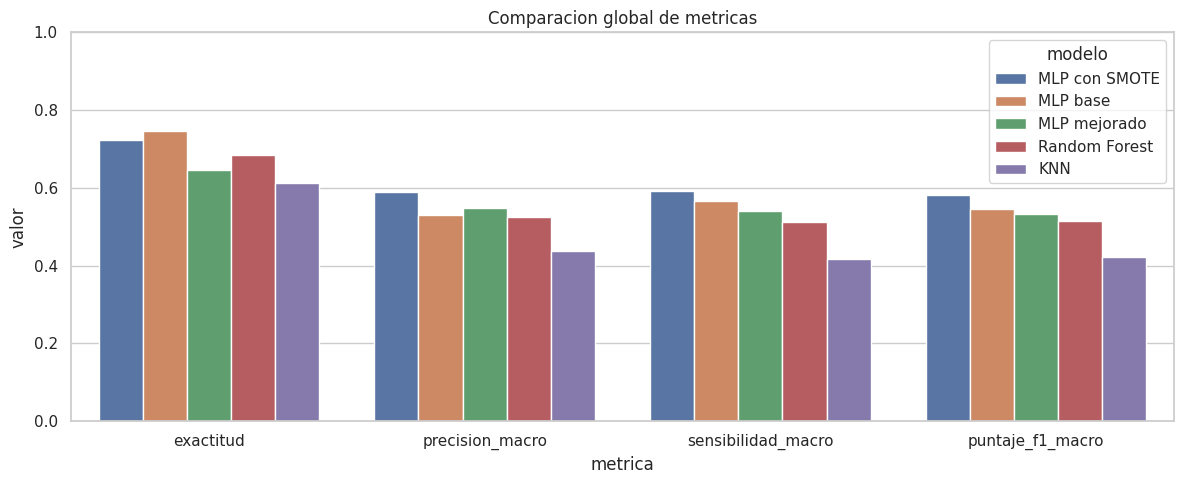

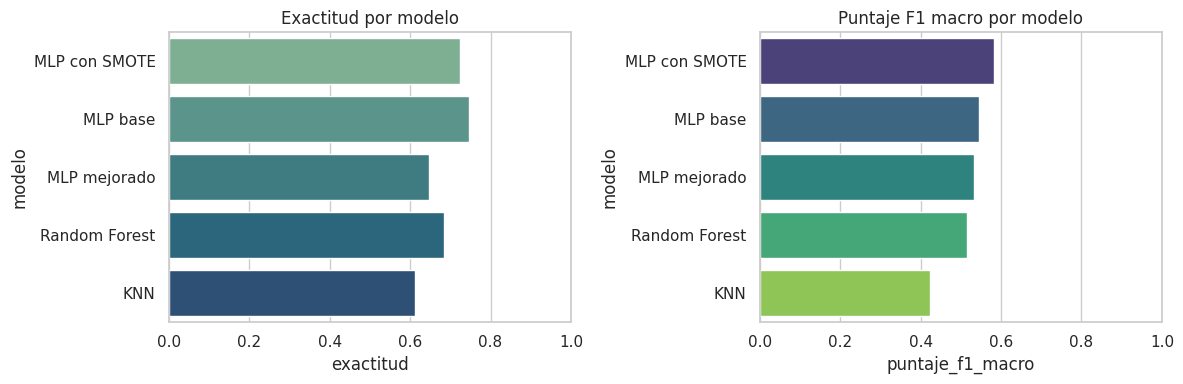

In [32]:
graficar_metricas(df_comparacion, 'Comparacion global de metricas')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=df_comparacion, x='exactitud', y='modelo', hue='modelo', dodge=False, palette='crest', legend=False, ax=axes[0])
axes[0].set_title('Exactitud por modelo')
axes[0].set_xlim(0, 1)
sns.barplot(data=df_comparacion, x='puntaje_f1_macro', y='modelo', hue='modelo', dodge=False, palette='viridis', legend=False, ax=axes[1])
axes[1].set_title('Puntaje F1 macro por modelo')
axes[1].set_xlim(0, 1)
plt.tight_layout()
plt.show()


Reporte de clasificacion - MLP mejorado
              precision    recall  f1-score   support

           0       0.29      0.31      0.30        16
           1       0.63      0.46      0.54        41
           2       0.48      0.55      0.52        58
           3       0.38      0.61      0.47        62
           4       0.94      0.76      0.84       182

    accuracy                           0.65       359
   macro avg       0.55      0.54      0.53       359
weighted avg       0.71      0.65      0.66       359


Reporte de clasificacion - MLP con SMOTE
              precision    recall  f1-score   support

           0       0.32      0.38      0.34        16
           1       0.57      0.41      0.48        41
           2       0.60      0.52      0.56        58
           3       0.52      0.77      0.62        62
           4       0.95      0.87      0.91       182

    accuracy                           0.72       359
   macro avg       0.59      0.59      0.58      

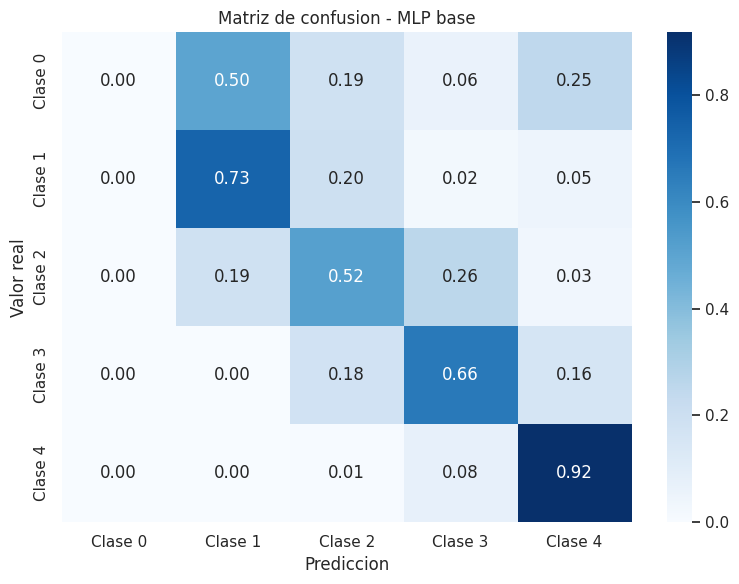

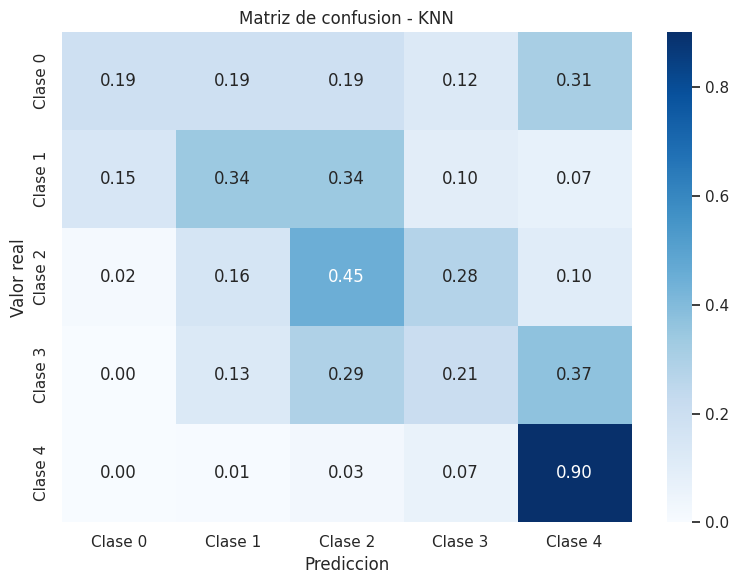

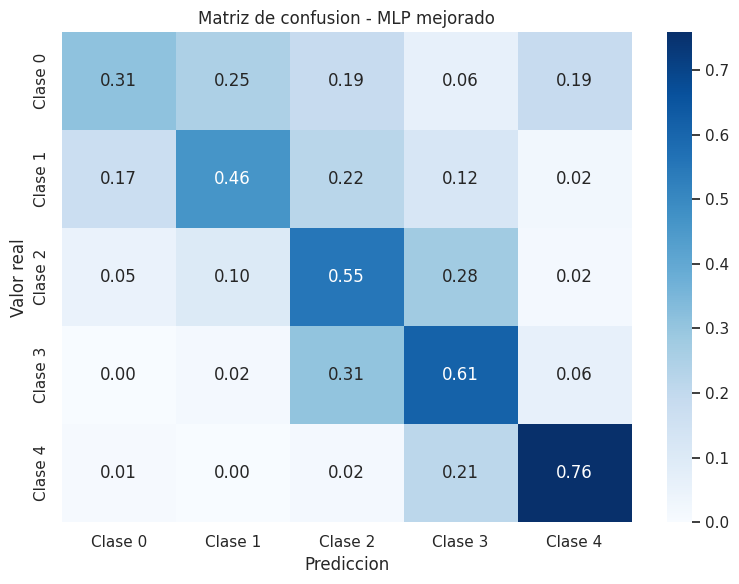

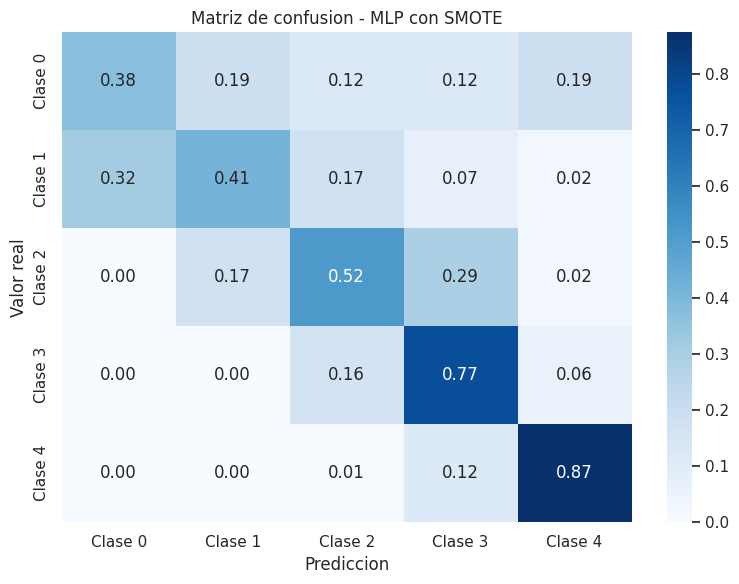

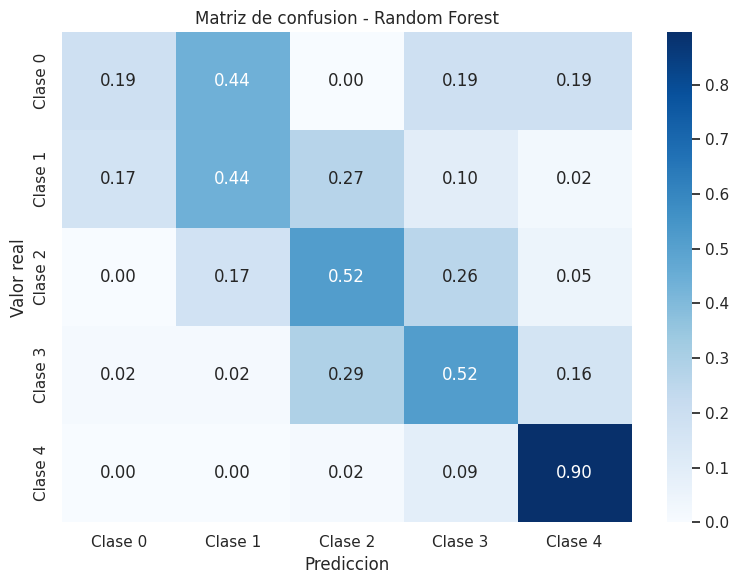

In [33]:
print('Reporte de clasificacion - MLP mejorado')
print(classification_report(y_test, pred_mlp_mejorado, zero_division=0))
print('\nReporte de clasificacion - MLP con SMOTE')
print(classification_report(y_test, pred_smote, zero_division=0))
print('\nReporte de clasificacion - Random Forest')
print(classification_report(y_test, pred_rf, zero_division=0))

etiquetas = sorted(np.unique(y_test).tolist())
mostrar_matriz_confusion(y_test, pred_base, etiquetas, 'Matriz de confusion - MLP base')
mostrar_matriz_confusion(y_test, pred_knn, etiquetas, 'Matriz de confusion - KNN')
mostrar_matriz_confusion(y_test, pred_mlp_mejorado, etiquetas, 'Matriz de confusion - MLP mejorado')
mostrar_matriz_confusion(y_test, pred_smote, etiquetas, 'Matriz de confusion - MLP con SMOTE')
mostrar_matriz_confusion(y_test, pred_rf, etiquetas, 'Matriz de confusion - Random Forest')


## 12. Importancia de variables con Random Forest

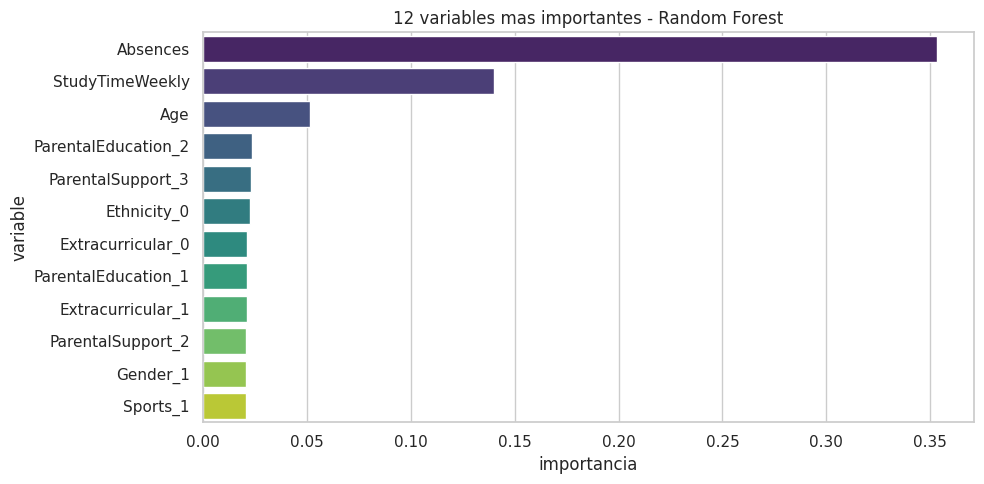

,variable,importancia
2,Absences,0.353397
1,StudyTimeWeekly,0.139968
0,Age,0.051720
11,ParentalEducation_2,0.023413
19,ParentalSupport_3,0.023262
5,Ethnicity_0,0.022776
21,Extracurricular_0,0.021170
10,ParentalEducation_1,0.021027
22,Extracurricular_1,0.021022
18,ParentalSupport_2,0.020969


In [34]:
nombres_variables = list(preprocesador.named_transformers_['continuas'].get_feature_names_out(COLUMNAS_CONTINUAS)) + list(preprocesador.named_transformers_['categoricas'].get_feature_names_out(COLUMNAS_CATEGORICAS))
df_importancia_rf = pd.DataFrame({'variable': nombres_variables, 'importancia': mejor_modelo_rf.feature_importances_}).sort_values('importancia', ascending=False).head(12)
plt.figure(figsize=(10, 5))
sns.barplot(data=df_importancia_rf, x='importancia', y='variable', hue='variable', dodge=False, palette='viridis', legend=False)
plt.title('12 variables mas importantes - Random Forest')
plt.tight_layout()
plt.show()
df_importancia_rf


## 13. Exportacion para el reporte

In [35]:
df_comparacion.to_csv(BASE_DIR / 'comparacion_modelos_notebook.csv', index=False)
df_resultados_mlp.to_csv(BASE_DIR / 'resultados_hiperparametros_mlp.csv', index=False)
df_resultados_smote.to_csv(BASE_DIR / 'resultados_hiperparametros_smote.csv', index=False)
df_resultados_rf.to_csv(BASE_DIR / 'resultados_hiperparametros_random_forest.csv', index=False)
df_importancia_rf.to_csv(BASE_DIR / 'importancia_variables_random_forest.csv', index=False)
print('Archivos exportados:')
print(BASE_DIR / 'comparacion_modelos_notebook.csv')
print(BASE_DIR / 'resultados_hiperparametros_mlp.csv')
print(BASE_DIR / 'resultados_hiperparametros_smote.csv')
print(BASE_DIR / 'resultados_hiperparametros_random_forest.csv')
print(BASE_DIR / 'importancia_variables_random_forest.csv')


Archivos exportados:
/home/dgx/jupyterlab/examen1-RedesNeuronales/comparacion_modelos_notebook.csv
/home/dgx/jupyterlab/examen1-RedesNeuronales/resultados_hiperparametros_mlp.csv
/home/dgx/jupyterlab/examen1-RedesNeuronales/resultados_hiperparametros_smote.csv
/home/dgx/jupyterlab/examen1-RedesNeuronales/resultados_hiperparametros_random_forest.csv
/home/dgx/jupyterlab/examen1-RedesNeuronales/importancia_variables_random_forest.csv


## 14. Observaciones para el reporte IEEE

- El conjunto de datos esta desbalanceado, especialmente en la clase 4.
- Eliminar `GPA` evita fuga de informacion y produce una evaluacion mas realista.
- El MLP base debe reportarse como el modelo principal exigido por el enunciado.
- KNN funciona como modelo base de comparacion simple.
- La variante con `SMOTE` puede mejorar el equilibrio entre clases.
- Random Forest sirve como modelo comparativo robusto respaldado por literatura para datos tabulares.
